# Day-ahead unit commitment for the Sri Lankan power grid

7COSC013W.1 Foundations of AI · CW1 · Danuja Wijerathna (20251143)

Can the Ceylon Electricity Board's daily scheduling decisions be improved? Four AI methods
answer the same question on the same days, scored against a proven optimum. The reasoning
behind each choice is in the technical report; this notebook is the implementation.

## The task environment

| | |
|---|---|
| **Performance measure** | Rupees of generation cost for the day, subject to zero constraint violations. Feasibility is reported beside cost and never blended into it: a cheap schedule that cannot be run is not a better schedule, and one number would hide exactly the failure that matters. |
| **Environment** | Partially observable (reservoir inflows, plant outages and the transmission network are not in the record), stochastic (tomorrow's demand is forecast, not known), sequential (committing at 16:00 decides what is possible at 19:00), static within one solve, discrete in time and in the on/off decisions but continuous in output, single-agent. |
| **Actuators** | The commitment matrix: 33 units by 96 intervals, on or off, and the output level under it. |
| **Sensors** | PUCSL's 15-minute generation record, the published daily cost reports, and the plant metadata. |

## Setup A · Dependencies

Checks what is already installed and installs only what is missing, so a re-run on a machine that already has them costs nothing and prints one line. `scipy` carries a floor because the exact solver in section 7 uses `scipy.optimize.milp`, which does not exist before 1.9.

In [1]:
import importlib.util

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy>=1.9",
    "sklearn": "scikit-learn",
    "networkx": "networkx",
    "yaml": "pyyaml",
}

missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("installing:", ", ".join(missing))
    !pip install --quiet {" ".join(missing)}
    print("done")
else:
    print("all packages already installed")

all packages already installed


## Setup B · Code and data

Fetched only when they are not already beside the notebook, so this does nothing on a machine with the project checked out. The bundle holds the analysis package, the derived CSVs, the cost tables and the cached result tables.

In [2]:
import io
import pathlib
import sys
import tarfile
import urllib.error
import urllib.request

BUNDLE_URL = (
    "https://dispatch-lab-demo-600307630560.s3.ap-south-1.amazonaws.com"
    "/bundle-b9b9578e278c3389/dispatch-lab-bundle.tar.gz"
)

ROOT = pathlib.Path.cwd()
# One file stands for the whole bundle. If the biggest data file is here, everything is.
if (ROOT / "pucsl_cache" / "csv" / "actual_15min.csv").exists():
    print("project files: already present")
else:
    print("project files: fetching bundle, about 24 MB ...")
    try:
        with urllib.request.urlopen(BUNDLE_URL) as response:
            payload = response.read()
    except urllib.error.HTTPError as err:
        raise RuntimeError(
            f"bundle unavailable ({err.code}). It is hosted for 30 days from 9 August 2026 and is "
            "then deleted. Run this notebook from the project directory, where the data is already "
            "present and no download is needed."
        ) from None
    with tarfile.open(fileobj=io.BytesIO(payload)) as archive:
        # `filter="data"` refuses absolute paths and parent traversal. It is the default from
        # Python 3.14 and unavailable before 3.11.4, so it is requested rather than assumed.
        try:
            archive.extractall(ROOT, filter="data")
        except TypeError:
            archive.extractall(ROOT)
    print(f"project files: unpacked into {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

project files: already present


In [3]:
import json
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dispatchlab import (arm_anneal, arm_forecast, arm_milp, arm_rules, costs, data,
                         evaluate, knowledge, model, params, prepare)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e3e2df", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 1.8,
})

## 1 · Data

PUCSL publishes generation at 15-minute resolution per plant. Everything here reads a local cache — the API was measured at roughly 10 % availability, so depending on it at run time would make the notebook unrunnable at the worst possible moment.

In [4]:
d = data.load()
cost_basis = costs.CostBasis(d)

print(f"{len(d.actual):,} plant-intervals   {d.actual.date.nunique()} local days")
print(f"{d.actual.date.min()} to {d.actual.date.max()}")
print(f"{len(d.committable())} committable units, {len(d.aggregates())} must-take aggregates")
print(f"costs: {cost_basis.coverage()}")

2,386,390 plant-intervals   675 local days
2023-12-01 to 2026-07-24
33 committable units, 5 must-take aggregates
costs: {'published_days': 358, 'from': '2023-10-16', 'to': '2025-03-18', 'mapping': {'energy_type': 21, 'published_fuel': 13, 'inferred_from_complex': 4}}


## 2 · Preparation
### 2.1 · Audit

The pipeline has two branches. The optimisation arms solve one day at a time and cannot leak across days, so what they need is *calibration* — constraints the real schedule actually satisfies.

In [5]:
report = prepare.audit(d, cost_basis)
report.frame()

,stage,check,value,note
0,1 type/timezone,GATE evening peak 18:30-19:30,PASS,"median 19:00, 93% of days"
1,2 de-duplication,"GATE no repeated (interval, plant)",PASS,0 remaining
2,3 structural,regimes,"B,C","64,573 intervals"
3,3 structural,contiguous blocks,4,"[837, 41045, 3128, 19563]"
4,3 structural,committable / must-take,33 / 5,
5,4 missingness,intervals absent across span,30.4%,left absent by policy - an absent plant is not...
6,4 missingness,capacity unreported (0 means not stated),8960,falls back to observed
7,5 outliers,GATE target |z|>4 after outage filter,PASS,range 769-3161 MW
8,6 integrity,GATE 15-min integrates to published daily energy,PASS,"median ratio 1.0012 over 18,902 plant-days"
9,6 integrity,GATE record satisfies its own constraints,PASS,0.242% of unit-intervals over 3 days


In [6]:
failures = report.failures()
print("gate failures:", "none" if failures.empty else failures.to_dict("records"))

gate failures: none


### 2.2 · Missingness, stated per field

Thirty per cent of the span is absent — a 292-day hole where an API outage stopped the fetch, plus two blackouts. None of it is imputed.

In [7]:
wide = d.wide()
blocks = data.blocks(wide.index)
span = pd.date_range(wide.index.min(), wide.index.max(), freq="15min", tz=data.LK)

sizes = [int((blocks == b).sum()) for b in np.unique(blocks)]
print(f"expected intervals over span : {len(span):,}")
print(f"present                      : {len(wide):,}  ({100 * len(wide) / len(span):.1f}%)")
print(f"contiguous blocks            : {sizes}  ({[round(s/96) for s in sizes]} days)")

expected intervals over span : 92,737
present                      : 64,573  (69.6%)
contiguous blocks            : [837, 41045, 3128, 19563]  ([9, 428, 33, 204] days)


### 2.3 · Outliers, treated by mechanism

Every anomaly found in this data had a cause, and the cause dictated the fix. A blanket z-score trim would have hidden all three:
| Symptom | Cause | Treatment |
|---|---|---|
| Canyon at 130 MW against a 60 MW rating, once in 64,573 intervals | instrument error | robust quantile instead of `max()` |
| Diesel at 5,954 Rs/kWh | fixed cost divided by 0.001 GWh | marginal cost is the fuel term only |
| 1.73 GWh generated at zero fuel cost | inconsistent source report | reject, carry the last real price forward |

In [8]:
demand = d.demand()
z = (demand - demand.mean()) / demand.std()
print(f"demand {demand.min():.0f}–{demand.max():.0f} MW, "
      f"|z|>4: {int((z.abs() > 4).sum())}, |z|>5: {int((z.abs() > 5).sum())}")

demand 769–3161 MW, |z|>4: 0, |z|>5: 0


### 2.4 · The problem the forecast branch actually has

Recorded demand in the test period is about a quarter higher than in training, and a model that learns absolute megawatts on the earlier data has no way to extrapolate that.

In [9]:
solar_ids = [u for u in wide.columns if "Rooftop" in str(d.meta.loc[u, "name"])]
in_b = wide.index < pd.Timestamp("2026-01-01", tz=data.LK)
total, without = wide.sum(axis=1), wide.drop(columns=solar_ids).sum(axis=1)

shift_all = 100 * (total[~in_b].mean() / total[in_b].mean() - 1)
shift_rest = 100 * (without[~in_b].mean() / without[in_b].mean() - 1)
share = 100 * wide[solar_ids][~in_b].sum(axis=1).mean() / total[~in_b].mean()

print(f"recorded demand, train -> test        : {shift_all:+.1f}%")
print(f"the same, excluding rooftop entries   : {shift_rest:+.1f}%")
print(f"rooftop share of the feed, train      : "
      f"{100 * wide[solar_ids][in_b].sum(axis=1).mean() / total[in_b].mean():.2f}%")
print(f"rooftop share of the feed, test       : {share:.2f}%")
print(f"\nshare of the level shift that is the reporting change: "
      f"{100 * (shift_all - shift_rest) / shift_all:.0f}%")

recorded demand, train -> test        : +24.3%
the same, excluding rooftop entries   : +3.8%
rooftop share of the feed, train      : 0.00%
rooftop share of the feed, test       : 16.48%

share of the level shift that is the reporting change: 84%


So the headline is not load growth. Roughly five sixths of the apparent rise is a change in what the feed counts, not in what the country consumed.

In [10]:
train_cut = pd.Timestamp("2025-04-01", tz=data.LK)
test_cut = pd.Timestamp("2026-01-01", tz=data.LK)
B, C = demand[demand.index < train_cut], demand[demand.index >= test_cut]


def mape(actual, forecast):
    keep = actual > 0
    return float(np.mean(np.abs((actual[keep] - forecast[keep]) / actual[keep])) * 100)


profile = B.groupby([B.index.dayofweek, B.index.hour, B.index.minute]).mean()
keys = [(t.dayofweek, t.hour, t.minute) for t in C.index]
predicted = np.array([profile.get(k, np.nan) for k in keys])
ok = ~np.isnan(predicted)

trailing = C.rolling(prepare.WEEK, min_periods=96).mean().shift(prepare.HORIZON).to_numpy()
causal = ok & ~np.isnan(trailing)

print(f"level shift, train to test          : {100 * (C.mean() / B.mean() - 1):+.0f}%")
print(f"profile learned on B, applied raw   : MAPE {mape(C.values[ok], predicted[ok]):5.2f}%")
print(f"  rescaled by the true ratio        : MAPE "
      f"{mape(C.values[ok], predicted[ok] * (C.mean() / B.mean())):5.2f}%   (oracle, not usable)")
print(f"  restored from a trailing window   : MAPE "
      f"{mape(C.values[causal], (predicted * trailing / B.mean())[causal]):5.2f}%   (causal)")

level shift, train to test          : +24%
profile learned on B, applied raw   : MAPE 19.13%
  rescaled by the true ratio        : MAPE 10.36%   (oracle, not usable)
  restored from a trailing window   : MAPE  9.72%   (causal)


Halving the error by predicting shape and restoring level is worth having, and the trailing window uses nothing unavailable at the forecast origin. The oracle rescale is shown only to bound what a perfect level estimate would buy — it turns out to be slightly *worse* than the causal version, because a single ratio cannot track drift within the test period.

### 2.5 · Baselines

The usual advice for electricity load is that a weekly seasonal naive is much stronger than a daily one. On this system that is not quite true, so the baseline is chosen from the data rather than from the literature.

In [11]:
for period, label in [(prepare.DAY, "daily"), (prepare.WEEK, "weekly")]:
    b = prepare.seasonal_naive(d, period=period)
    print(f"{label:7s} seasonal naive: MAPE {b['mape']:5.2f}%   "
          f"MAE {b['mae']:6.1f} MW   RMSE {b['rmse']:6.1f}   n={b['n']:,}")

daily   seasonal naive: MAPE  7.39%   MAE  157.9 MW   RMSE  240.6   n=19,467


weekly  seasonal naive: MAPE  7.70%   MAE  160.3 MW   RMSE  255.0   n=18,891


### 2.6 · Splitting, before anything is fitted

Train on regime B, test on regime C, with the 2025 gap sitting between them. Model selection uses rolling origins inside the training block — k-fold would shuffle time and let the model see its own future.

In [12]:
ds = prepare.forecast_dataset(d)

print(f"train {ds.X_train.shape}   {ds.notes['train_span'][0][:10]} to {ds.notes['train_span'][1][:10]}")
print(f"test  {ds.X_test.shape}   {ds.notes['test_span'][0][:10]} to {ds.notes['test_span'][1][:10]}")
print(f"features: {', '.join(ds.feature_names)}")
print()
print(f"no overlap                : {ds.X_train.index.max() < ds.X_test.index.min()}")
print(f"scaled train centred      : {np.abs(ds.X_train.mean()).max():.3f}")
print(f"scaled test left alone    : {np.abs(ds.X_test.mean()).max():.3f}")
print(f"folds train before testing: {all(a.max() < b.min() for a, b in ds.folds)}")
print()
print(f"raw level shift           : {ds.notes['level_shift_pct']:+.1f}%")
print(f"normalised target, train  : mean {ds.y_train.mean():.3f}  sd {ds.y_train.std():.3f}")
print(f"normalised target, test   : mean {ds.y_test.mean():.3f}  sd {ds.y_test.std():.3f}")

train (42994, 14)   2023-12-08 to 2025-03-14
test  (18891, 14)   2026-01-08 to 2026-07-24
features: tod_sin, tod_cos, dow_sin, dow_cos, month_sin, month_cos, is_weekend, lag_96, lag_97, lag_192, lag_672, roll_d_mean, roll_w_mean, lag_day_minus_week

no overlap                : True
scaled train centred      : 0.000
scaled test left alone    : 0.811
folds train before testing: True

raw level shift           : +23.9%
normalised target, train  : mean 1.002  sd 0.186
normalised target, test   : mean 1.005  sd 0.182


The last two lines are the point of the exercise. A raw level difference of nearly a quarter has become two distributions that agree to three decimal places, so the model can spend its capacity on shape instead of on a trend it could never extrapolate.

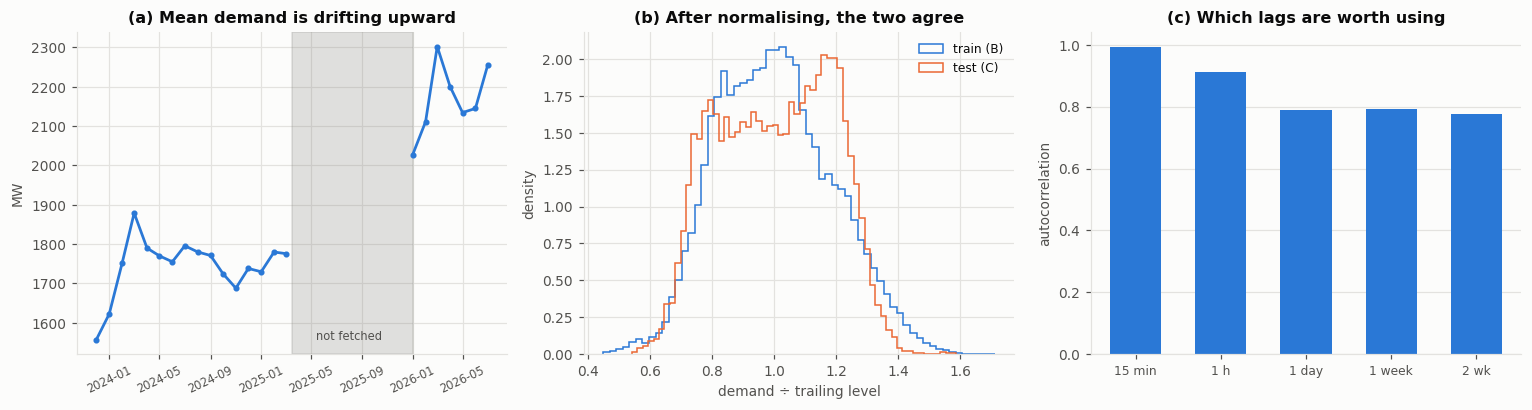

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = axes[0]
monthly = demand.resample("MS").mean()
ax.plot(monthly.index, monthly.values, color=CAT[0], marker="o", ms=3)
ax.axvspan(pd.Timestamp("2025-03-15", tz=data.LK), pd.Timestamp("2026-01-01", tz=data.LK),
           color="#8a8a86", alpha=0.25)
ax.text(pd.Timestamp("2025-08-01", tz=data.LK), monthly.min(), "not fetched",
        fontsize=7.5, color=INK2, ha="center")
ax.set_ylabel("MW"); ax.set_title("(a) Mean demand is drifting upward")
ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)

ax = axes[1]
for k, (name, series) in enumerate([("train (B)", ds.y_train), ("test (C)", ds.y_test)]):
    ax.hist(series, bins=60, histtype="step", density=True, color=CAT[k], label=name)
ax.set_xlabel("demand ÷ trailing level"); ax.set_ylabel("density")
ax.set_title("(b) After normalising, the two agree"); ax.legend(fontsize=8)

ax = axes[2]
lags = [1, 4, 96, 672, 1344]
biggest = max(set(blocks), key=lambda b: (blocks == b).sum())
inside = demand[blocks == biggest]
ax.bar(range(len(lags)), [inside.autocorr(l) for l in lags], color=CAT[0], width=0.6)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels(["15 min", "1 h", "1 day", "1 week", "2 wk"], fontsize=8)
ax.set_ylabel("autocorrelation"); ax.set_title("(c) Which lags are worth using")
ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

Panel (c) is why the feature set uses lags of one day and one week and nothing shorter. The 15-minute autocorrelation is 0.99, which looks irresistible until you remember the forecast is made once, the evening before — at a 96-step horizon that value does not exist yet, and using it would be a leak dressed up as a feature.

## 3 · Model parameters

Nothing here is a textbook default. Every limit comes out of what the operator actually did, because a constraint invented for the model is one the benchmark never had to satisfy, and the comparison stops meaning anything.

In [14]:
unit_params = params.unit_params(d)
unit_params[["name", "energy_type", "pmin", "pmax", "pmax_source",
             "ramp_mw_per_step", "min_up_h", "min_up_identified", "duty"]].round(2)

,name,energy_type,pmin,pmax,pmax_source,ramp_mw_per_step,min_up_h,min_up_identified,duty
unit,,,,,,,,,
1,Sapu. Station - A,Oil (CEB),7.00,84.00,published,42.00,3.05,True,0.57
3,Old Laxapana,Major Hydro,9.00,56.00,published,35.00,0.25,False,1.00
4,Canyon,Major Hydro,10.00,60.00,published,30.43,2.00,True,0.76
5,New Laxapana,Major Hydro,10.00,145.00,published,59.00,0.50,False,0.99
6,Wimalasurendra,Major Hydro,5.00,102.80,published,34.00,1.75,True,0.69
7,Polpitiya,Major Hydro,11.00,90.00,published,39.00,405.50,False,0.99
8,Broadlands,Major Hydro,9.00,36.00,published,18.00,1.25,True,0.75
9,Kotmale,Major Hydro,22.00,212.00,published,80.00,1.41,True,0.57
10,Victoria,Major Hydro,19.00,243.00,observed_exceeds_published,84.00,2.10,True,0.97


`min_up_identified` matters. Lakvijaya's third unit and Polpitiya have three complete on-spells each across 675 days, so a percentile of those is interpolation between two arbitrary points.

In [15]:
print("reserve :", {k: (round(v, 4) if isinstance(v, float) else v)
                    for k, v in params.derive_reserve(d).items()})
print("min sync:", params.derive_min_sync(d))

reserve : {'reserve_fraction': 0.2147, 'median_deliverable_fraction': 0.4043, 'quantile_used': 0.01, 'n': 48463}
min sync: {'min_sync_units': 8, 'observed_min': 7, 'before_blackout': 8, 'after_blackout': 9, 'n_before': 41837, 'n_after': 22736}


Reserve is capped by what each unit can actually deliver inside one interval. Counting every running machine's unused capacity instead gives about 70 % of demand — true arithmetic, meaningless operationally, since most of that could not arrive in fifteen minutes.

### 3.1 · Calibration

The test that keeps all of the above honest: run CEB's own schedule through the constraints derived from it. Anything the operator did that the model calls impossible is a defect in the model.

In [16]:
calibration = params.calibrate(
    d, cost_basis,
    ["2024-06-15", "2024-09-20", "2025-01-20", "2026-01-15", "2026-03-04", "2026-06-10"],
    unit_params_frame=unit_params,
)
calibration[["over_pmax", "under_pmin", "ramp_exceeded", "reserve_short",
             "min_sync_short", "unserved_mw", "violation_rate"]]

,over_pmax,under_pmin,ramp_exceeded,reserve_short,min_sync_short,unserved_mw,violation_rate
date,,,,,,,
2024-06-15,0,7,0,0,0,0.0,0.002841
2024-09-20,0,5,0,1,0,0.0,0.001894
2025-01-20,1,3,0,1,0,0.0,0.002210
2026-01-15,0,32,4,0,0,0.0,0.011995
2026-03-04,0,4,2,0,0,0.0,0.002210
2026-06-10,0,0,2,0,0,0.0,0.000947


A small residue is expected and not worth chasing. The bounds sit at the thousandth quantiles, so a handful of genuinely extreme intervals fall outside; tightening to zero would mean setting every limit at the record maximum, at which point the constraints stop constraining anything.

## 4 · Knowledge representation

The scheduling knowledge is held as a typed graph rather than a table, because the questions asked of it are relational. "Which units could have covered Kelanitissa at 17:15" is a traversal, and the answer has to survive being asked how it knows.

In [17]:
kg = knowledge.build(d, costs=cost_basis.as_map("2026-03-04"))
summary = kg.summary()
print("nodes:", summary["nodes"])
print("edges:", summary["edges"])

provenance = pd.Series(
    [a.get("provenance") for _, a in kg.g.nodes(data=True)]
).value_counts()
print("\nnode provenance:", provenance.to_dict())

nodes: {'Unit': 33, 'Complex': 13, 'FuelType': 9, 'Rule': 9, 'Injection': 5, 'Basin': 2}
edges: {'substitutes_for': 332, 'burns': 38, 'belongs_to': 38, 'precedes_in_merit': 32, 'coupled_with': 16, 'in_basin': 12}

node provenance: {'published': 40, 'measured': 20, 'structural': 6, 'asserted': 5}


### 4.1 · The part that is not in the data

Two hydraulic cascades are asserted from the scheme layouts: the Mahaweli chain and the Kelani/Laxapana complex. Membership is geography.

In [18]:
coupled = [
    (kg.g.nodes[a]["name"], kg.g.nodes[b]["name"], at["r"], at["lag_steps"])
    for a, b, at in kg.g.edges(data=True) if at["rel"] == "coupled_with"
]
basin_of = {
    u: kg.related(u, "in_basin")[0] if kg.related(u, "in_basin") else None
    for u in kg.units()
}
lookup = {kg.g.nodes[u]["name"]: basin_of[u] for u in kg.units()}

pairs = pd.DataFrame(
    sorted({tuple(sorted((a, b))) + (round(r, 3), lag) for a, b, r, lag in coupled}),
    columns=["unit_a", "unit_b", "r", "lag_steps"],
).sort_values("r", ascending=False)
pairs["same_basin"] = [lookup.get(a) == lookup.get(b) is not None
                       for a, b in zip(pairs.unit_a, pairs.unit_b)]
print(pairs.head(10).to_string(index=False))
print(f"\nmeasured couplings inside an asserted basin: "
      f"{pairs.same_basin.sum()} of {len(pairs)}")

      unit_a         unit_b     r  lag_steps  same_basin
 Randenigala       Rantambe 0.815          0        True
New Laxapana      Polpitiya 0.772          2        True
  Broadlands      Polpitiya 0.728          1        True
Old Laxapana      Polpitiya 0.683          2        True
 Randenigala       Victoria 0.599          1        True
      Canyon   New Laxapana 0.584          0        True
    Rantambe       Victoria 0.582          0        True
Old Laxapana Wimalasurendra 0.551          1        True

measured couplings inside an asserted basin: 8 of 8


### 4.2 · Inference

Every measured coupling falls inside a basin that was asserted independently. That is corroboration, not proof — the correlation would also appear if two stations simply followed the same demand curve — but it is the strongest check available, and it would have failed loudly had the basins been drawn wrongly.

In [19]:
rules = pd.DataFrame([
    {"rule": r["id"], "kind": r["kind"], "basis": r.get("basis", "asserted"),
     "text": " ".join(r["text"].split())[:72]}
    for r in kg.rules["rules"]
])
print(rules.to_string(index=False))

                 rule   kind      basis                                                                     text
       reserve_margin system   measured    Committed capacity must exceed demand by the spinning reserve margin.
      min_synchronous system   measured At least N synchronous machines must be online, so that there is enough 
min_stable_generation   unit   measured         A committed unit must run at or above its minimum stable output.
          min_up_down   unit   measured Once started a unit must stay on for its minimum up time; once stopped i
           ramp_limit   unit   measured      Output cannot change by more than the ramp limit between intervals.
            must_take   unit structural Fleet aggregates are injections, not decisions - their output is taken a
   hydraulic_coupling   unit   asserted Units on the same cascade share water, so their output moves together an
   hydro_peak_shaving   unit   asserted A hydro unit's daily water is spent against the highest 

`must_run` is deliberately empty, and that emptiness is a finding. Duty cycle looked like the obvious way to identify must-run plant, but the distribution turns out to be a smooth continuum rather than the bimodal split that would justify a threshold — and the units sitting near 100 % are the hydro machines, which run constantly because their marginal cost is near zero.

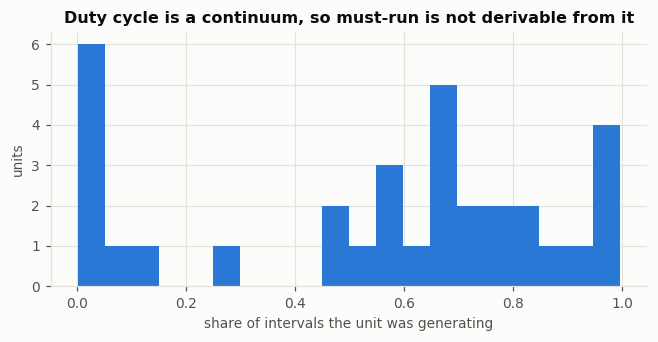

        name energy_type     duty
Old Laxapana Major Hydro 0.996206
   Polpitiya Major Hydro 0.994735
New Laxapana Major Hydro 0.987115
    Victoria Major Hydro 0.965264
      LVPS 3        Coal 0.919548
      LVPS 2        Coal 0.882629


In [20]:
duty = unit_params[["name", "energy_type", "duty"]].sort_values("duty", ascending=False)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(duty.duty, bins=20, color=CAT[0])
ax.set_xlabel("share of intervals the unit was generating"); ax.set_ylabel("units")
ax.set_title("Duty cycle is a continuum, so must-run is not derivable from it")
plt.show()
print(duty.head(6).to_string(index=False))

## 5 · Arm A — merit order over the graph

The operator's own logic, made inspectable: walk the merit relation, commit until demand plus reserve is covered, with the rule engine forcing and vetoing along the way. Hydro is handled separately because merit order cannot cope with it — at zero fuel cost a reservoir always looks like the best plant on the system, but its constraint is energy, not capacity, so committing it round the clock spends the water by mid-afternoon.

In [21]:
DAY_SHOWN = "2026-03-04"
instance = model.build_instance(d, DAY_SHOWN, cost_basis, unit_params=unit_params)
ceb = model.observed_schedule(d, instance)
arm_a = arm_rules.solve(instance, kg)

print(pd.DataFrame([ceb.summary(), arm_a.summary()]).to_string(index=False))
print("\nwhy each commitment happened:", arm_a.meta["trace"].counts())

                  label  fuel_cost_rs_m  start_cost_rs_m  total_cost_rs_m  co2_tonnes  starts  peak_mw  violations  feasible
             CEB actual          904.23             4.14           908.38     24862.5      25   2844.0           7     False
Merit order (rule base)          907.28            14.45           921.73     24794.7      42   2844.0           3     False

why each commitment happened: {'hydro_peak_shaving': 1344, 'merit_order': 734, 'decommit_surplus': 75, 'min_up_down': 164}


### 5.1 · Asking the rule base to account for itself

Recording why a unit was committed is the easy half. The harder and more useful question is why one was not, because that is what an operator disagreeing with the schedule actually asks.

In [22]:
tr = arm_a.meta["trace"]
T_SHOWN = int(np.argmax(instance.net_demand()))
off = [u for i, u in enumerate(instance.units) if arm_a.commitment[T_SHOWN, i] == 0]
on = [u for i, u in enumerate(instance.units) if arm_a.commitment[T_SHOWN, i] == 1]
name = dict(zip(instance.units, instance.names))

print(f"peak interval {T_SHOWN}: {len(on)} units on, {len(off)} off\n")
print("WHY was this unit committed")
for u in on[:2]:
    for e in tr.why(T_SHOWN, u):
        print(f"  {name[u]:<22} {e['rule']:<20} {e['detail']}")

print("\nWHY NOT this one")
for u in off[:4]:
    a = tr.why_not(T_SHOWN, u)
    print(f"  {name[u]:<22} {a['rule']:<20} {a['detail']}")

print("\nreasons for every uncommitted unit-interval in the day:")
print(pd.Series([
    tr.why_not(t, u)["rule"]
    for t in range(instance.n_periods)
    for i, u in enumerate(instance.units) if arm_a.commitment[t, i] == 0
]).value_counts().to_string())

peak interval 76: 31 units on, 2 off

WHY was this unit committed
  Sapu. Station - A      merit_order          committed to reach 3455 MW incl reserve
  Old Laxapana           hydro_peak_shaving   water aimed at this interval, ~19 MW

WHY NOT this one
  LVPS 3                 min_up_down          inside its minimum down time of 24.00 h after stopping
  KPS_DPP_HAMBA          min_up_down          inside its minimum down time of 2.34 h after stopping

reasons for every uncommitted unit-interval in the day:
merit_order           406
min_up_down           360
hydro_peak_shaving    160
decommit_surplus       75


The last table is a check on the rule base as much as a demonstration. Every unit-interval that is off has a named cause, and the mix says what is actually driving the schedule: if `merit_order` dominates the day is being decided by price, and if `min_up_down` dominates it is being decided by machines that cannot legally move.

In [23]:
whatif = arm_rules.what_if(instance, kg,
                           reserve_fraction=instance.reserve_fraction + 0.10)
print(f"reserve {instance.reserve_fraction:.3f} -> {instance.reserve_fraction + 0.10:.3f}")
print(f"  unit-intervals changed : {whatif['unit_intervals_changed']}")
print(f"  units affected         : {[name[u] for u in whatif['units_affected'][:6]]}")
print(f"  starts                 : {whatif['starts_before']} -> {whatif['starts_after']}")

reserve 0.215 -> 0.315
  unit-intervals changed : 259
  units affected         : ['Sapu. Station - A', 'Sapu. Station - B', 'Uthuru Janani', 'Power Barge', 'DPP_KPS_Mathu', 'LVPS 3']
  starts                 : 42 -> 42


Read that as an explanation of the rule base, not as the price of reserve. Arm A commits greedily and loads greedily, so carrying more capacity relieves its own dispatch and the day comes out looking cheaper.

Arm A costs more than what CEB actually ran. That is the expected result and it is the reason the next two arms exist: merit order decides each interval on its own merits, so it cannot pay something extra at 16:00 to avoid paying far more at 19:00.

## 6 · Arm B — simulated annealing
### 6.1 · Start temperature, from the observed move distribution

Search over the binary commitment matrix, with the loading underneath solved exactly as a linear program. The arms therefore differ in which machines they synchronise and in nothing else, which is what makes comparing them fair.

In [24]:
rng = np.random.default_rng(RANDOM_SEED)
neigh = arm_anneal.Neighbourhood(instance, kg=kg, rng=rng)
start_u = neigh.repair(arm_a.commitment.copy())
base_score, _, _ = arm_anneal.score(instance, start_u)
deltas = arm_anneal.sample_deltas(instance, neigh, start_u, base_score, n=300)
uphill = deltas[deltas > 0]

print(f"{len(deltas)} random moves, {len(uphill)} uphill "
      f"({100 * len(uphill) / len(deltas):.0f}%)")
print("uphill cost, Rs m: " + "  ".join(
    f"p{q}={np.percentile(uphill, q) / 1e6:.2f}" for q in (25, 50, 75, 90, 99)))
print(f"mean {uphill.mean() / 1e6:.2f}   median {np.median(uphill) / 1e6:.2f}   "
      f"ratio {uphill.mean() / np.median(uphill):.0f}x")
print(f"\nT0 at chi0=0.8 from the mean  : "
      f"{-uphill.mean() / np.log(0.8) / 1e6:7.2f} Rs m")
print(f"T0 at chi0=0.8 from the median: "
      f"{arm_anneal.start_temperature(deltas, 0.8) / 1e6:7.2f} Rs m")

300 random moves, 153 uphill (51%)
uphill cost, Rs m: p25=0.22  p50=2.01  p75=37.22  p90=72.36  p99=358.66
mean 29.15   median 2.01   ratio 14x

T0 at chi0=0.8 from the mean  :  130.65 Rs m
T0 at chi0=0.8 from the median:    9.02 Rs m


Half of all uphill moves cost about a rupee-million; a fifth of them stop a machine the evening peak needed and are paid for in unserved energy at a million rupees per MWh. That tail puts the mean an order of magnitude above the median, so a temperature calibrated on it is describing catastrophes rather than typical steps — and a search that starts that hot accepts almost anything.

In [25]:
def cached(name):
    return pd.read_json(evaluate.RESULTS / f"{name}.json", orient="table")


tune_days, test_days = evaluate.day_split()
print(f"tuning days (held out, never reported on): {[str(x) for x in tune_days]}")
print(f"reporting days: {[str(x) for x in test_days]}")

tuning days (held out, never reported on): ['2024-01-04', '2024-01-26', '2024-02-03', '2026-01-11', '2026-01-17', '2026-04-27']
reporting days: ['2023-12-11', '2024-02-12', '2024-05-23', '2024-06-27', '2024-07-16', '2025-03-09', '2026-02-16', '2026-03-09', '2026-03-21', '2026-05-25', '2026-06-28', '2026-07-21']


### 6.2 · Operator weights, from measured yield

Three operators: flip one interval, flip a run the length of the unit's minimum up time, or swap a unit for one the graph considers comparable. Rather than assume they are equally useful, a pilot ran them uniformly and measured what each won per proposal.

In [26]:
pilot = cached("anneal_operator_pilot")
per_op = pilot.groupby("operator").agg(
    proposals=("proposals", "sum"),
    improving=("improving", "sum"),
    total_gain_rs=("total_gain_rs", "sum"),
)
per_op["improve_rate"] = per_op["improving"] / per_op["proposals"]
per_op["gain_per_proposal_rs_m"] = per_op["total_gain_rs"] / per_op["proposals"] / 1e6
weights = json.loads((evaluate.RESULTS / "anneal_operator_weights.json").read_text())
per_op["weight"] = pd.Series(weights)
print(per_op.round(4).to_string())

          proposals  improving  total_gain_rs  improve_rate  gain_per_proposal_rs_m  weight
operator                                                                                   
run            3733        888   3.844576e+09        0.2379                  1.0299  0.5152
single         1559        358   6.636673e+08        0.2296                  0.4257  0.2130
swap           5508       1388   2.992657e+09        0.2520                  0.5433  0.2718


### 6.3 · How long to run, from the convergence curve

The iteration budget is read off the plateau rather than chosen.

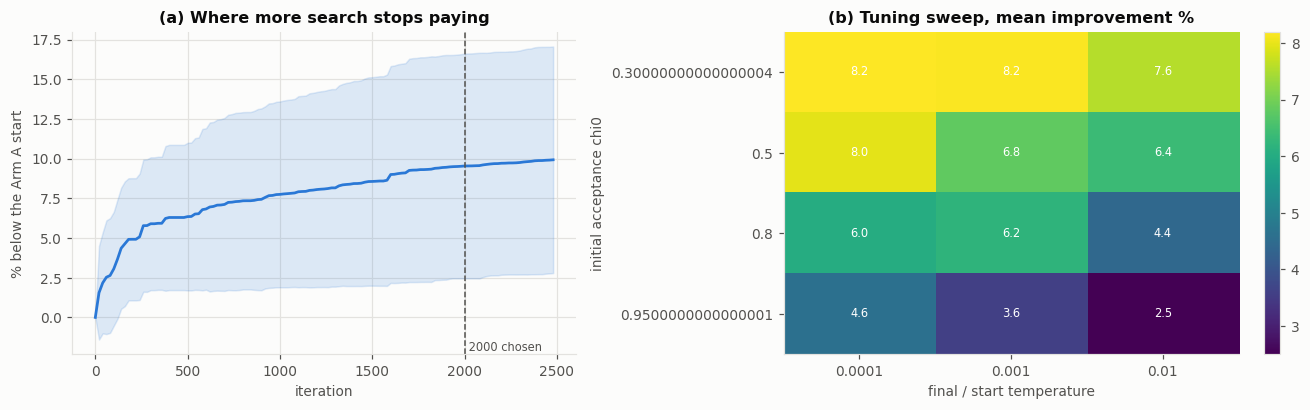

chosen: {'chi0': 0.30000000000000004, 't_final_ratio': 0.0001, 'iterations': 2000, 'chosen_on': ['2024-01-04', '2024-01-26', '2024-02-03', '2026-01-11', '2026-01-17', '2026-04-27'], 'mean_improvement_pct': 8.197016588066667}


In [27]:
conv = cached("anneal_convergence")
conv["start"] = conv.groupby(["date", "seed"])["best_rs_m"].transform("first")
conv["gain_pct"] = 100 * (conv["start"] - conv["best_rs_m"]) / conv["start"]
curve = conv.groupby("iteration")["gain_pct"].agg(["mean", "std"])
settings = json.loads((evaluate.RESULTS / "anneal_settings.json").read_text())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.plot(curve.index, curve["mean"], color=CAT[0])
ax.fill_between(curve.index, curve["mean"] - curve["std"], curve["mean"] + curve["std"],
                color=CAT[0], alpha=0.15)
ax.axvline(settings["iterations"], color=INK2, ls="--", lw=1)
ax.text(settings["iterations"], ax.get_ylim()[0], f" {settings['iterations']} chosen",
        fontsize=7.5, color=INK2, va="bottom")
ax.set_xlabel("iteration"); ax.set_ylabel("% below the Arm A start")
ax.set_title("(a) Where more search stops paying")

ax = axes[1]
tuning = cached("anneal_tuning")
grid = tuning.groupby(["chi0", "t_final_ratio"])["improvement_pct"].mean().unstack()
im = ax.imshow(grid.to_numpy(), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels([f"{c:g}" for c in grid.columns])
ax.set_yticks(range(len(grid.index))); ax.set_yticklabels(grid.index)
ax.set_xlabel("final / start temperature"); ax.set_ylabel("initial acceptance chi0")
ax.set_title("(b) Tuning sweep, mean improvement %")
ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.to_numpy()[i, j]:.1f}", ha="center", va="center",
                fontsize=7.5, color="w")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); plt.show()

print("chosen:", {k: v for k, v in settings.items() if k != "weights"})

### 6.4 · One run, in full

In [28]:
arm_b = arm_anneal.solve(instance, kg=kg, seed=RANDOM_SEED,
                         iterations=settings["iterations"], chi0=settings["chi0"],
                         t_final_ratio=settings["t_final_ratio"],
                         weights=settings["weights"], start=arm_a.commitment)
trace = arm_b.meta["trace"].frame()
print(pd.DataFrame([ceb.summary(), arm_a.summary(), arm_b.summary()]).to_string(index=False))
print(f"\naccepted {arm_b.meta['accept_rate']:.0%} of moves, "
      f"{arm_b.meta['worse_accept_rate']:.0%} of them uphill; "
      f"{arm_b.meta['proposals_per_move']:.2f} proposals per priced move")

                  label  fuel_cost_rs_m  start_cost_rs_m  total_cost_rs_m  co2_tonnes  starts  peak_mw  violations  feasible
             CEB actual          904.23             4.14           908.38     24862.5      25   2844.0           7     False
Merit order (rule base)          907.28            14.45           921.73     24794.7      42   2844.0           3     False
    Simulated annealing          822.87             3.45           826.32     25552.0      28   2844.0           0      True

accepted 35% of moves, 12% of them uphill; 2.13 proposals per priced move


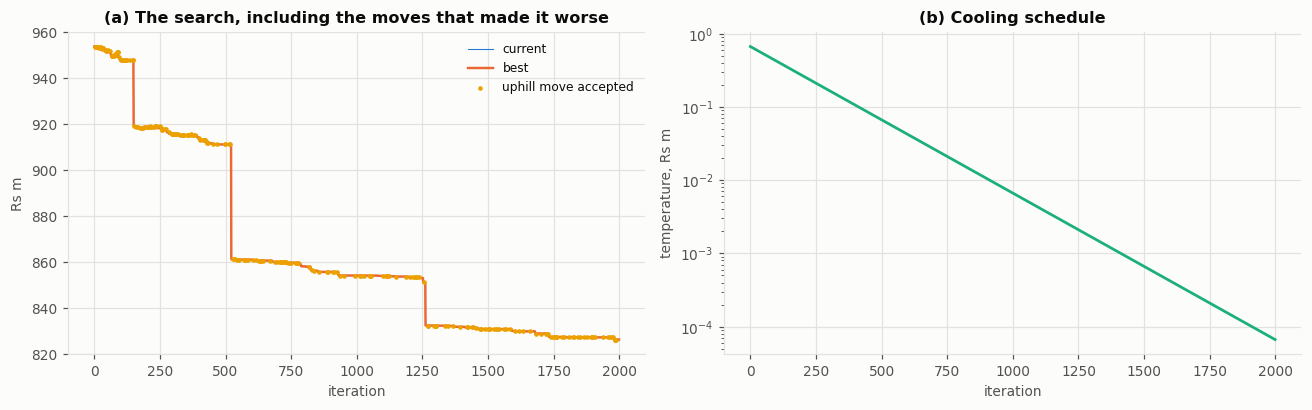

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.plot(trace.iteration, trace.current / 1e6, color=CAT[0], lw=0.7, label="current")
ax.plot(trace.iteration, trace.best / 1e6, color=CAT[1], lw=1.6, label="best")
uphill_taken = trace[trace.accepted_worse]
ax.scatter(uphill_taken.iteration, uphill_taken.current / 1e6, s=4, color=CAT[3],
           label="uphill move accepted", zorder=3)
ax.set_xlabel("iteration"); ax.set_ylabel("Rs m"); ax.legend(fontsize=8)
ax.set_title("(a) The search, including the moves that made it worse")

ax = axes[1]
ax.plot(trace.iteration, trace.temperature / 1e6, color=CAT[2])
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("temperature, Rs m")
ax.set_title("(b) Cooling schedule")
fig.tight_layout(); plt.show()

## 7 · Arm C — the exact answer
### 7.1 · How large an instance can be proved

The heuristics answer "can we find a cheaper schedule". This answers "how much cheaper can any schedule be", which is the only question that turns a saving into a claim.

In [30]:
size_curve = cached("milp_size_curve")
print(size_curve.round(3).to_string(index=False))

 periods  units  binaries  rows  runtime_s  proven  mip_gap  replay_unserved_mwh  optimum_rs_m
      24      8       576  1602      0.116    True      0.0              604.646       938.415
      24     12       864  2369      0.218    True      0.0              159.028       841.289
      24     20      1440  3903      1.826    True      0.0                0.000       802.476
      24     33      2376  6391      4.933    True      0.0                0.000       814.690
      48      8      1152  3210      0.272    True      0.0              609.523       938.627
      48     12      1728  4745      0.921    True      0.0              185.076       860.630
      48     20      2880  7815      4.091    True      0.0                0.000       802.583
      48     33      4752 12799     53.937    True      0.0                0.000       815.301
      96      8      2304  6426      2.029    True      0.0             1184.317       944.667
      96     12      3456  9497      8.425    True

The full day — 96 intervals, 33 units, 9,504 binaries — does not close inside the time limit, which is what the reduction exists for. Everything smaller does: 48 intervals in 54 s, 24 in 5 s.

In [31]:
reduced = arm_milp.reduce_instance(instance, ceb.output, periods=24)
exact, milp_meta = arm_milp.solve(reduced, "tight", time_limit=600)
print({k: v for k, v in milp_meta.items()
       if k in ("n_binary", "n_rows", "runtime_s", "nodes", "mip_gap", "proven")})
print(f"\nproven optimum: {milp_meta['objective_rs'] / 1e6:.3f} Rs m")
print(f"violations in the optimal schedule: {exact.violations()['total']}")

{'runtime_s': 4.188843727111816, 'mip_gap': 0.0, 'nodes': 1, 'n_binary': 2376, 'n_rows': 6391, 'proven': True}

proven optimum: 814.690 Rs m
violations in the optimal schedule: 0


### 7.2 · Does the tight formulation earn its reputation here?

The claim in the literature is that the tight formulation cuts a large share of the integrality gap. On these instances it does not, and saying so is more useful than repeating the citation.

In [32]:
study = cached("milp_formulation_study")
print(study.round(4).to_string(index=False))

      date  periods  units  tight_root_rs_m  tight_best_rs_m  tight_runtime_s  tight_nodes  tight_gap  tight_proven  tight_binaries  tight_rows  naive_root_rs_m  naive_best_rs_m  naive_runtime_s  naive_nodes  naive_gap  naive_proven  naive_binaries  naive_rows  tight_integrality_gap_pct  naive_integrality_gap_pct
2026-03-04       24     33         814.5924         814.6898           4.7672            1        0.0          True            2376        6391         814.5907         814.6898          16.7483            1        0.0          True             792        7183                     0.0120                     0.0122
2024-06-15       24     33         473.0871         473.0871           7.2660            1        0.0          True            2376        6391         473.0871         473.0871           7.6825            1        0.0          True             792        7183                    -0.0000                    -0.0000
2026-01-15       24     33         364.2108         364

Both formulations reach the same integer optimum on every day, which is the strongest correctness check available without an external reference — two independently written models of one problem agreeing.

### 7.3 · What each method can and cannot promise

Cost and runtime are not the only axes the arms differ on. Two of them return an answer that is provably the best available and three do not, and that distinction matters more than a few per cent of cost when deciding which to trust.

In [33]:
effort = pd.DataFrame([
    {"arm": "Exhaustive enumeration", "complete": "yes", "optimal": "yes, by construction",
     "search effort": "every one of 2^(T x N) commitments", "scope": "3-4 units, 4 intervals"},
    {"arm": "MILP tight (Arm C)", "complete": "yes", "optimal": "yes, proven 12/12 days",
     "search effort": f"{int(study.tight_nodes.min())}-{int(study.tight_nodes.max())} nodes",
     "scope": "24 intervals x 33 units"},
    {"arm": "MILP naive", "complete": "yes", "optimal": "yes, proven",
     "search effort": f"{int(study.naive_nodes.min())}-{int(study.naive_nodes.max())} nodes",
     "scope": "24 intervals x 33 units"},
    {"arm": "Annealing (Arm B)", "complete": "no", "optimal": "no, anytime",
     "search effort": f"{settings['iterations']} candidates priced, 2.07 proposals each",
     "scope": "96 intervals x 33 units"},
    {"arm": "Hill climbing (T = 0)", "complete": "no", "optimal": "no, local optimum",
     "search effort": f"{settings['iterations']} candidates priced, no uphill moves",
     "scope": "96 intervals x 33 units"},
    {"arm": "Merit order (Arm A)", "complete": "constructive", "optimal": "no",
     "search effort": "one pass, no backtracking", "scope": "96 intervals x 33 units"},
])
print(effort.to_string(index=False))

                   arm     complete                optimal                               search effort                   scope
Exhaustive enumeration          yes   yes, by construction          every one of 2^(T x N) commitments  3-4 units, 4 intervals
    MILP tight (Arm C)          yes yes, proven 12/12 days                                  1-38 nodes 24 intervals x 33 units
            MILP naive          yes            yes, proven                                1-2267 nodes 24 intervals x 33 units
     Annealing (Arm B)           no            no, anytime 2000 candidates priced, 2.07 proposals each 96 intervals x 33 units
 Hill climbing (T = 0)           no      no, local optimum     2000 candidates priced, no uphill moves 96 intervals x 33 units
   Merit order (Arm A) constructive                     no                   one pass, no backtracking 96 intervals x 33 units


The exact arms are complete and optimal but bounded in the size they can prove; the heuristic arms scale to the real instance and promise nothing. That is the trade the whole evaluation turns on, and it is why the two are used together rather than one being chosen: Arm B does the work at full resolution and Arm C says how much better anyone could have done on a size where the question has a provable answer.

## 8 · Arm D — day-ahead demand, and what getting it wrong costs
### 8.1 · The bar

Every arm above is handed the demand that actually occurred, which no operator ever has. This one predicts it from what was knowable the evening before.

In [34]:
ds = prepare.forecast_dataset(d)
print(arm_forecast.baselines(d).round(3).to_string(index=False))

                  model     n  mape     mae    rmse
 seasonal naive (daily) 19467 7.385 157.929 240.553
seasonal naive (weekly) 18891 7.701 160.251 255.002


### 8.2 · Features have to live in the same space as the target

The target is demand divided by a trailing weekly level, because test-period load runs 24 % above training and a model fitted on absolute megawatts is extrapolating a trend it cannot see. The lag features have to be divided by the same thing, and getting that wrong was the difference between beating the baseline and losing to it.

In [35]:
comparison = cached("forecast_feature_study")
print(comparison.round(3).to_string(index=False))

                       features  mape     mae
                 lags in raw MW 8.041 167.390
lags relative to trailing level 5.478 114.994
          both raw and relative 6.618 143.673
      seasonal naive (no model) 7.365 157.590


With lags in raw megawatts the model scores 8.0 % and loses to a naive baseline at 7.4 %, which looked at first like a modelling failure. It was a units mismatch: asked for a ratio and handed absolute MW, the model has to reconstruct the level before it can say anything about shape, and on a period running a quarter above training it reconstructs it wrongly.

In [36]:
cv = cached("forecast_cv")
print(cv.head(6).round(4).to_string(index=False))

best = {k: cv.iloc[0][k] for k in
        ("learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf",
         "l2_regularization")}
best = {k: (int(v) if k in ("max_iter", "max_leaf_nodes", "min_samples_leaf") else float(v))
        for k, v in best.items()}
forecaster = arm_forecast.fit(ds, **best)
print("\nselected by rolling-origin CV inside the training block:", best)
print("train:", {k: round(v, 3) for k, v in arm_forecast.score(forecaster, ds, "train").items()})
print("test :", {k: round(v, 3) for k, v in arm_forecast.score(forecaster, ds, "test").items()})

 learning_rate  max_iter  max_leaf_nodes  min_samples_leaf  l2_regularization  cv_mape_mean  cv_mape_sd  folds
          0.03       200              31                40                1.0        6.5301      1.1492      4
          0.03       200              15                40                1.0        6.5397      1.1262      4
          0.06       200              15                40                1.0        6.5549      1.1011      4
          0.03       400              15                40                1.0        6.5723      1.0946      4
          0.03       400              31                40                1.0        6.5920      1.1945      4
          0.06       200              31                40                1.0        6.5951      1.1301      4


selected by rolling-origin CV inside the training block: {'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
train: {'mape': 4.34, 'mae': 71.037, 'rmse': 101.454, 'n': 42994}
test : {'mape': 5.472, 'mae': 114.615, 'rmse': 178.642, 'n': 18891}


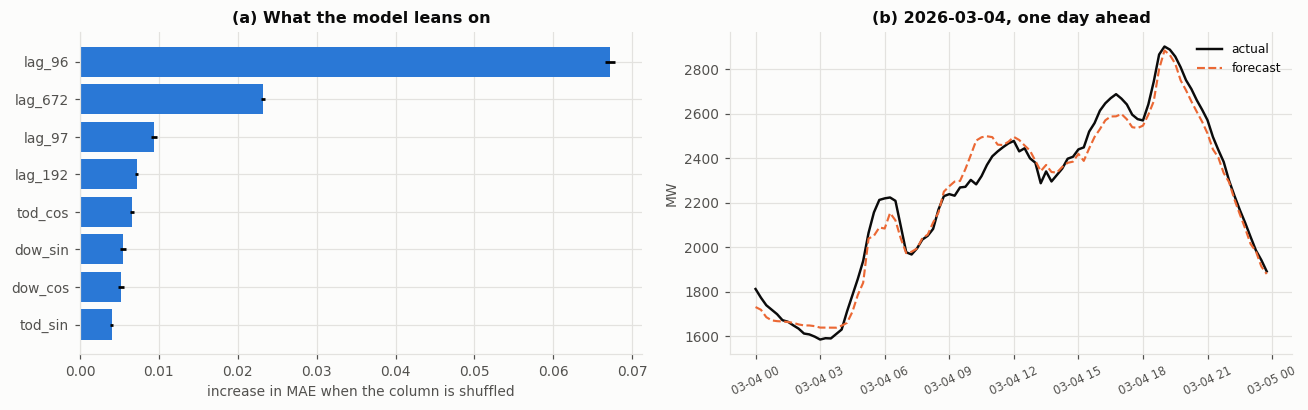

In [37]:
importance = cached("forecast_importance")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
top = importance.head(8).iloc[::-1]
ax.barh(top.feature, top.importance, color=CAT[0], xerr=top["sd"])
ax.set_xlabel("increase in MAE when the column is shuffled")
ax.set_title("(a) What the model leans on")

ax = axes[1]
day = ds.X_test.index.date == pd.Timestamp(DAY_SHOWN).date()
if day.sum():
    hours = ds.X_test.index[day]
    ax.plot(hours, ds.restore(ds.y_test[day], "test", where=day),
            color=INK, lw=1.6, label="actual")
    ax.plot(hours, ds.restore(forecaster.predict(ds.X_test[day]), "test", where=day),
            color=CAT[1], lw=1.4, ls="--", label="forecast")
    ax.legend(fontsize=8); ax.set_ylabel("MW")
    ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)
ax.set_title(f"(b) {DAY_SHOWN}, one day ahead")
fig.tight_layout(); plt.show()

### 8.3 · Closing the loop

The decomposition that makes this arm worth having. Schedule against the forecast, pay against the outcome: commit to what you expected and be billed for what happened.

In [38]:
loop = cached("forecast_loop")
print(loop.round(3).to_string(index=False))
print(f"\nmean cost of forecast error: {loop.penalty_pct.mean():.2f}% of the day's bill")
print(f"correlation between forecast MAPE and cost penalty: "
      f"{loop.mape.corr(loop.penalty_pct):.2f}")

      date  mape  perfect_rs_m  billed_rs_m  penalty_rs_m  penalty_pct  unserved_mwh
2026-02-16 4.835       821.724      832.923        11.199        1.363           0.0
2026-03-09 5.794       914.373      976.857        62.484        6.834           0.0
2026-03-21 3.390       941.265      966.347        25.082        2.665           0.0
2026-05-25 3.473       762.964      796.956        33.992        4.455           0.0
2026-06-28 6.630       662.175      727.494        65.319        9.864           0.0
2026-07-21 2.876       874.310      964.213        89.903       10.283           0.0

mean cost of forecast error: 5.91% of the day's bill
correlation between forecast MAPE and cost penalty: 0.22


Committing on the forecast and paying for the outcome costs about 6 % of the day's bill, and no day sheds load — the schedule absorbs the error rather than failing.

## 9 · Is the solver right?
### 9.1 · Exhaustive enumeration

Everything so far checks the arms against each other. That has already earned its keep — the two MILP formulations disagreeing is how a transposed pair of coefficients was found — but two models written by one person from one understanding can be wrong together.

In [39]:
from dispatchlab import benchmarks

small = benchmarks.small_instance(instance, ceb.output, n_units=3, periods=4)
validation, truth = benchmarks.validate(small, kg=kg, seeds=(0, 1, 2), iterations=200)
print(f"{small.n_periods} periods x {small.n_units} units "
      f"= {2 ** (small.n_periods * small.n_units):,} possible commitments")
print(validation.round(5).to_string(index=False))

4 periods x 3 units = 4,096 possible commitments
                    method  cost_rs_m  ratio  proven                           detail
    exhaustive enumeration  266.52905    1.0    True 617 legal of 4,096, 0.0 MWh shed
               MILP, tight  266.52905    1.0    True                gap 0.0e+00, 0.0s
               MILP, naive  266.52905    1.0    True                gap 0.0e+00, 0.0s
       merit order (Arm A)  266.52905    1.0   False                                 
annealing (Arm B), 3 seeds  266.52905    1.0   False best 266.529, worst 266.529 Rs m


### 9.2 · The external benchmark, and why it is not solved here

Both formulations, the rule base and the search all land on the enumerated optimum exactly.

In [40]:
gap, pglib_meta = benchmarks.pglib_gap()
print(pglib_meta)
print(gap.to_string(index=False))

{'instance': 'rts_gmlc_2020-03-05.json', 'periods': 48, 'thermal_units': 73, 'renewable_units': 81, 'demand_mw': (2993.42, 4328.01), 'representable_features': 3, 'total_features': 8}
                                    feature                                            pglib                                  this_project  representable
           piecewise convex production cost                              4-4 points per unit              single slope (Rs/kWh from PUCSL)          False
           off-time dependent start-up cost                23 of 73 units have multiple lags one start-up cost per unit, assumed and swept          False
dispatchable renewables with a min/max band                                         81 units  must-take injection, no curtailment decision          False
  separate start-up / shut-down ramp limits ramp_startup_limit, ramp_shutdown_limit per unit      one cap of max(pmin, ramp) at both edges          False
  initial on/off history before the horizon    

Three of eight features carry across; five do not. Piecewise convex production costs and off-time dependent start-up costs are the two that matter most — PUCSL publishes a single Rs/kWh figure per plant type, so this project has one slope per unit and one start-up cost, and no amount of care makes those represent a four-point cost curve or a start-up price that depends on how long the machine has been cold.

## 10 · Evaluation

Twelve reporting days, drawn per regime and disjoint from the six the search was tuned on. Annealing is stochastic, so it is repeated over fifteen seeds — five would put the smallest achievable Wilcoxon p-value at 0.031, which is too weak to conclude anything from.

In [41]:
arms = cached("evaluation_arms")
per_arm = arms.groupby("arm").agg(
    days=("date", "nunique"),
    runs=("total_rs_m", "size"),
    mean_rs_m=("total_rs_m", "mean"),
    sd_rs_m=("total_rs_m", "std"),
    infeasible=("violations", lambda s: int((s > 0).sum())),
).sort_values("mean_rs_m")
print(per_arm.round(3).to_string())

                                days  runs  mean_rs_m  sd_rs_m  infeasible
arm                                                                       
Annealing, blind neighbourhood    12    60    560.443  241.617           0
Annealing (Arm B)                 12   180    566.189  243.579           1
CEB actual                        12    12    568.166  249.048           7
CEB day-ahead plan                12    12    576.439  231.702          12
Commit everything                 12    12    624.934  184.778          12
Merit order (Arm A)               12    12    629.768  261.976           9
Random commitment                 12    12   1156.693  267.158          12


### 10.1 · What the CEB baseline is, exactly

Cost and feasibility are reported separately throughout. A cheap schedule that cannot be run is not a better answer, and averaging the two into one score would hide exactly the failure mode worth catching.

In [42]:
from dispatchlab.dispatch import economic_dispatch

rows = []
for day in [str(x) for x in test_days]:
    inst_day = model.build_instance(d, day, cost_basis, unit_params=unit_params)
    raw = model.observed_schedule(d, inst_day)
    out, _ = economic_dispatch(inst_day, raw.commitment)
    rows.append({
        "date": day,
        "as_run_rs_m": raw.total_cost_rs() / 1e6,
        "redispatched_rs_m": model.Schedule(inst_day, raw.commitment, out).total_cost_rs() / 1e6,
    })
concession = pd.DataFrame(rows)
concession["lp_saving_pct"] = 100 * (
    concession.as_run_rs_m - concession.redispatched_rs_m) / concession.as_run_rs_m
print(concession.round(2).to_string(index=False))
print(f"\nmean {concession.lp_saving_pct.mean():.2f}% — what optimal loading alone is worth "
      f"on CEB's own commitment")

      date  as_run_rs_m  redispatched_rs_m  lp_saving_pct
2023-12-11       216.61             180.36          16.74
2024-02-12       675.96             657.42           2.74
2024-05-23       222.06             222.06           0.00
2024-06-27       308.31             299.80           2.76
2024-07-16       374.82             354.76           5.35
2025-03-09       662.71             589.14          11.10
2026-02-16       818.64             728.49          11.01
2026-03-09       941.58             864.32           8.21
2026-03-21      1031.26             856.60          16.94
2026-05-25       723.58             634.54          12.31
2026-06-28       662.56             570.61          13.88
2026-07-21       998.80             859.89          13.91

mean 9.58% — what optimal loading alone is worth on CEB's own commitment


Optimal loading, with the commitment left exactly as the operator set it, is worth 9.6 % of the bill on its own. So the baseline below has already been handed most of the available saving before the arms are allowed to start, and beating it is a far harder test than beating what the system actually cost.

In [43]:
paired = (arms.groupby(["date", "arm"])["total_rs_m"].mean().unstack())
reference = "CEB actual"
delta = paired.sub(paired[reference], axis=0).div(paired[reference], axis=0) * 100
print("saving against CEB actual, % of the day's bill (negative is cheaper)")
print(delta.describe().round(2).to_string())

saving against CEB actual, % of the day's bill (negative is cheaper)
arm    Annealing (Arm B)  Annealing, blind neighbourhood  CEB actual  CEB day-ahead plan  Commit everything  Merit order (Arm A)  Random commitment
count              12.00                           12.00        12.0               12.00              12.00                12.00              12.00
mean               -1.55                           -2.37         0.0                4.66              22.41                11.78             138.70
std                 7.53                            6.95         0.0               11.25              37.13                 8.64             119.89
min               -24.68                          -23.45         0.0               -3.69              -5.00                 1.68              57.69
25%                -0.65                           -1.97         0.0               -0.20               1.67                 5.36              75.69
50%                 1.07                   

### 10.2 · Is the difference real?

Friedman first, across all arms at once. Reading pairwise tests without it inflates the false-positive rate with this many comparisons.

In [44]:
long = paired.stack().rename("total_rs_m").reset_index()
overall = evaluate.friedman(long)
print(f"Friedman chi2 = {overall['statistic']:.1f}, p = {overall['p']:.2e}, "
      f"{overall['n_blocks']} days x {overall['n_arms']} arms")
print("\nmean rank (lower is cheaper):")
print(pd.Series(overall["mean_rank"]).sort_values().round(2).to_string())

Friedman chi2 = 52.1, p = 1.75e-09, 12 days x 7 arms

mean rank (lower is cheaper):
Annealing, blind neighbourhood    2.08
CEB actual                        2.25
Annealing (Arm B)                 3.08
CEB day-ahead plan                3.17
Commit everything                 5.00
Merit order (Arm A)               5.42
Random commitment                 7.00


In [45]:
pairs_test = evaluate.wilcoxon_pairs(long)
print(pairs_test.sort_values("p").round(4).to_string(index=False))

                             a                              b  n  statistic      p  median_diff_rs_m
Annealing, blind neighbourhood              Random commitment 12        0.0 0.0005         -576.8060
            CEB day-ahead plan              Random commitment 12        0.0 0.0005         -572.4542
                    CEB actual              Random commitment 12        0.0 0.0005         -574.8322
                    CEB actual            Merit order (Arm A) 12        0.0 0.0005          -63.0498
             Commit everything              Random commitment 12        0.0 0.0005         -559.4872
Annealing, blind neighbourhood            Merit order (Arm A) 12        0.0 0.0005          -72.2305
Annealing, blind neighbourhood              Commit everything 12        0.0 0.0005          -19.3755
           Merit order (Arm A)              Random commitment 12        0.0 0.0005         -523.2619
             Annealing (Arm B)              Random commitment 12        0.0 0.0005         

### 10.3 · Distribution, not just the mean

An ECDF shows dominance rather than asserting it: if one arm's curve lies entirely to the left of another's, it is cheaper on every day rather than on average.

/var/folders/_5/bzs6p0q14474ztyrsj4d5lsr0000gn/T/ipykernel_92945/862551861.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([seeded[seeded.arm == a]["total_rs_m"] for a in labels], labels=labels,


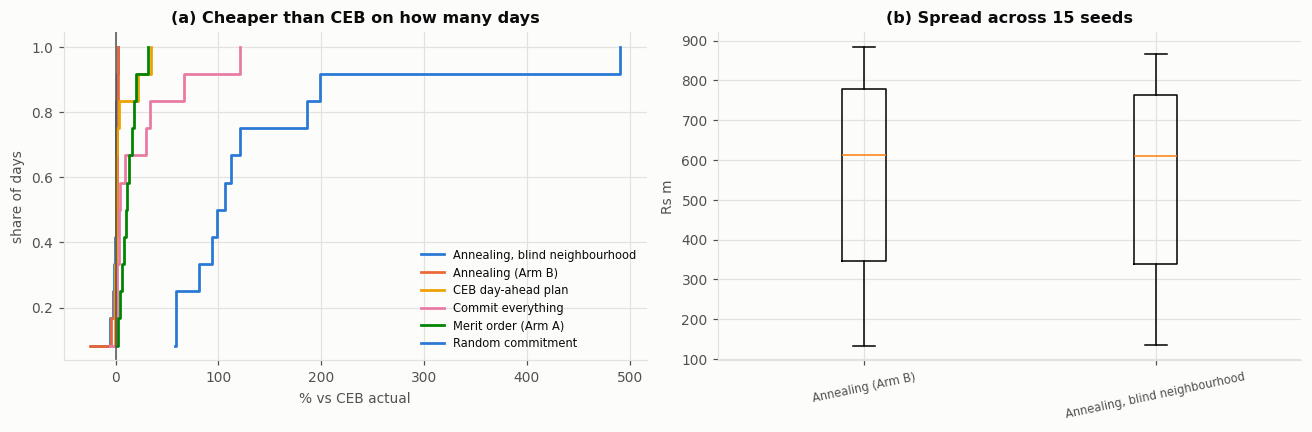

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for k, arm in enumerate(per_arm.index):
    values = delta[arm].dropna() if arm in delta else None
    if values is None or arm == reference:
        continue
    x, y = evaluate.ecdf(values)
    ax.step(x, y, where="post", color=CAT[k % len(CAT)], label=arm)
ax.axvline(0, color=INK2, lw=1)
ax.set_xlabel("% vs CEB actual"); ax.set_ylabel("share of days")
ax.set_title("(a) Cheaper than CEB on how many days"); ax.legend(fontsize=7.5)

ax = axes[1]
seeded = arms[arms.seed >= 0]
labels = sorted(seeded.arm.unique())
ax.boxplot([seeded[seeded.arm == a]["total_rs_m"] for a in labels], labels=labels,
           showfliers=False)
ax.set_ylabel("Rs m"); ax.tick_params(axis="x", labelrotation=12, labelsize=7.5)
ax.set_title("(b) Spread across 15 seeds")
fig.tight_layout(); plt.show()

### 10.4 · Optimality ratio

Against a proven optimum, not against the best thing found. Computed on the hourly reduction, where the MILP closes — every arm is re-run there, so the ratio compares answers to one question rather than to two.

In [47]:
reduced_results = cached("evaluation_reduced")
optimum = (reduced_results[reduced_results.arm.str.startswith("MILP")]
           .set_index("date")["total_rs_m"])
ratio = reduced_results.copy()
ratio["optimum_rs_m"] = ratio["date"].map(optimum)
ratio["optimality_ratio"] = ratio["total_rs_m"] / ratio["optimum_rs_m"]

table = ratio.groupby("arm")["optimality_ratio"].agg(["mean", "std", "min", "max"])
print(table.sort_values("mean").round(4).to_string())
milp_rows = reduced_results[reduced_results.arm.str.startswith("MILP")]
print(f"\nMILP proven on {int(milp_rows.proven.sum())} of {len(milp_rows)} days, "
      f"mean {milp_rows.runtime_s.mean():.0f}s, max {milp_rows.runtime_s.max():.0f}s")

                       mean     std     min     max
arm                                                
MILP (Arm C, tight)  1.0000  0.0000  1.0000  1.0000
Annealing (Arm B)    1.0147  0.0271  1.0000  1.1914
CEB commitment       1.0523  0.0972  1.0000  1.3543
Merit order (Arm A)  1.1367  0.1288  1.0216  1.4084
Commit everything    1.3156  0.5751  1.0213  3.0335
Random commitment    2.1236  1.3304  1.3213  6.1639

MILP proven on 12 of 12 days, mean 18s, max 44s


This is the table the project turns on, and it says something the full-resolution comparison could not.

## 11 · Ablations
### 11.1 · Does the knowledge graph actually help the search?

Each of these turns one thing off and re-solves, because that is the only way to say what it was contributing.

In [48]:
from scipy.stats import wilcoxon

sa = arms[arms.seed >= 0]
# Paired on the seeds both arms actually ran. The headline table averages 15
# guided seeds against 5 blind ones, which compares two estimators rather than
# two methods; restricting to the shared seeds removes that.
shared = sorted(set(sa[sa.guided == False].seed.unique()))
cells = sa[sa.seed.isin(shared)].pivot_table(
    index=["date", "seed"], columns="guided", values="total_rs_m").dropna()
cells.columns = ["blind", "guided"]

both = cells.groupby("date")[["guided", "blind"]].mean()
both["blind_cheaper_pct"] = 100 * (both.guided - both.blind) / both.guided
stat, p = wilcoxon(both.guided, both.blind)
print(both.round(3).to_string())
print(f"\nseeds compared: {shared}")
print(f"blind is cheaper by {both.blind_cheaper_pct.mean():+.2f}% on average, "
      f"on {int((both.blind_cheaper_pct > 0).sum())} of {len(both)} days")
print(f"Wilcoxon on day means: p = {p:.4f}")
print(f"guided over all 15 seeds {sa[sa.guided == True].total_rs_m.mean():.2f} vs "
      f"over the shared 5 {cells.guided.mean():.2f} Rs m — not a seed-budget artefact")

             guided    blind  blind_cheaper_pct
date                                           
2023-12-11  136.864  138.072             -0.883
2024-02-12  672.147  669.975              0.323
2024-05-23  224.141  225.007             -0.386
2024-06-27  303.131  301.797              0.440
2024-07-16  362.223  356.270              1.644
2025-03-09  580.566  578.834              0.298
2026-02-16  746.273  732.400              1.859
2026-03-09  822.861  815.297              0.919
2026-03-21  873.475  857.837              1.790
2026-05-25  640.583  637.223              0.525
2026-06-28  574.837  555.683              3.332
2026-07-21  857.822  856.918              0.105

seeds compared: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
blind is cheaper by +0.83% on average, on 10 of 12 days
Wilcoxon on day means: p = 0.0034
guided over all 15 seeds 566.19 vs over the shared 5 566.24 Rs m — not a seed-budget artefact


The graph makes the search *worse*, by 0.8 % on average, on ten of twelve days, and the result is significant. That is a negative result on something this project set out to claim, so it is worth establishing why rather than leaving it as a curiosity.

In [49]:
guided_pairs, blind_pairs = [], []
for flag, bucket in ((True, guided_pairs), (False, blind_pairs)):
    n = arm_anneal.Neighbourhood(instance, kg=kg, guided=flag,
                                 rng=np.random.default_rng(0))
    for i in range(instance.n_units):
        for j in n.substitutes[i]:
            bucket.append(abs(instance.marginal_cost[i] - instance.marginal_cost[j]))

for label, gaps in (("knowledge-guided", guided_pairs), ("blind", blind_pairs)):
    gaps = np.array(gaps)
    print(f"{label:17s} {len(gaps):5d} pairs   "
          f"median |cost gap| {np.median(gaps):6.3f} Rs/kWh   "
          f"under 1 Rs/kWh: {100 * np.mean(gaps < 1.0):3.0f}%")

tiers = {}
for i in range(instance.n_units):
    tier = kg.g.nodes[f"unit:{instance.units[i]}"].get("merit_tier")
    tiers.setdefault(tier, []).append(round(float(instance.marginal_cost[i]), 2))
print()
for tier, members in sorted(tiers.items(), key=lambda kv: (kv[0] is None, kv[0])):
    print(f"  merit tier {tier}: {len(members):2d} units, "
          f"{min(members)}–{max(members)} Rs/kWh")

knowledge-guided    332 pairs   median |cost gap|  0.000 Rs/kWh   under 1 Rs/kWh:  96%
blind              1056 pairs   median |cost gap| 43.590 Rs/kWh   under 1 Rs/kWh:  30%

  merit tier 0: 16 units, 0.0–0.0 Rs/kWh
  merit tier 1:  3 units, 19.19–19.19 Rs/kWh
  merit tier 2:  9 units, 43.61–45.41 Rs/kWh
  merit tier 3:  5 units, 89.0–89.0 Rs/kWh


There it is. `substitutes_for` joins units in the same merit tier with overlapping operating ranges, and because PUCSL publishes cost per plant *type* rather than per plant, every unit inside a tier has an **identical** marginal cost — sixteen hydro machines at 0.00, five oil units at 89.00.

### 11.2 · Does the annealing part of simulated annealing earn anything?

The same question asked of Arm B's own defining feature. Everything above compares the search against a greedy constructor, an exact solver and the operator, and all of those comparisons are about the neighbourhood and the repair step as much as about the acceptance rule.

In [50]:
hc = cached("hillclimb_ablation")
ANNEAL, HILL = "Annealing (Arm B)", "Hill climbing (T = 0)"

for resolution in ("reduced", "full"):
    part = hc[hc.resolution == resolution]
    if part.empty:
        continue
    by_day = part.pivot_table(index=["date", "seed"], columns="arm",
                              values="total_rs_m").groupby("date").mean()
    gain = 100 * (by_day[HILL] - by_day[ANNEAL]) / by_day[HILL]
    stat, p = wilcoxon(by_day[ANNEAL], by_day[HILL])
    label = "hourly reduction" if resolution == "reduced" else "full 96 intervals"
    ahead, margin = (ANNEAL, gain.mean()) if gain.mean() > 0 else (HILL, -gain.mean())
    print(f"{label}: annealing {by_day[ANNEAL].mean():.2f} vs "
          f"hill climbing {by_day[HILL].mean():.2f} Rs m")
    print(f"  cheaper on average: {ahead} by {margin:.2f}%")
    print(f"  annealing cheaper on {int((gain > 0).sum())} of {len(by_day)} days, "
          f"Wilcoxon p = {p:.4f}"
          f"{'  (not significant at 0.05)' if p >= 0.05 else ''}")
    print(f"  uphill moves annealing actually accepted: "
          f"{100 * part[part.arm == ANNEAL].worse_accept_rate.mean():.1f}% of iterations")
    print(f"  wall clock per solve: annealing {part[part.arm == ANNEAL].runtime_s.mean():.0f} s, "
          f"hill climbing {part[part.arm == HILL].runtime_s.mean():.0f} s")

hourly reduction: annealing 555.64 vs hill climbing 556.04 Rs m
  cheaper on average: Hill climbing (T = 0) by 0.13%
  annealing cheaper on 6 of 12 days, Wilcoxon p = 0.9097  (not significant at 0.05)
  uphill moves annealing actually accepted: 7.0% of iterations
  wall clock per solve: annealing 38 s, hill climbing 37 s
full 96 intervals: annealing 566.24 vs hill climbing 563.52 Rs m
  cheaper on average: Hill climbing (T = 0) by 0.65%
  annealing cheaper on 3 of 12 days, Wilcoxon p = 0.1294  (not significant at 0.05)
  uphill moves annealing actually accepted: 11.7% of iterations
  wall clock per solve: annealing 490 s, hill climbing 401 s


One asymmetry belongs in the reading of that table rather than out of sight. Both arms get the same iteration budget, but annealing additionally spends a probe of 80 linear-programme solves sampling the move distribution to set its start temperature, and hill climbing skips them.

### 11.3 · What the constraints and assumptions cost

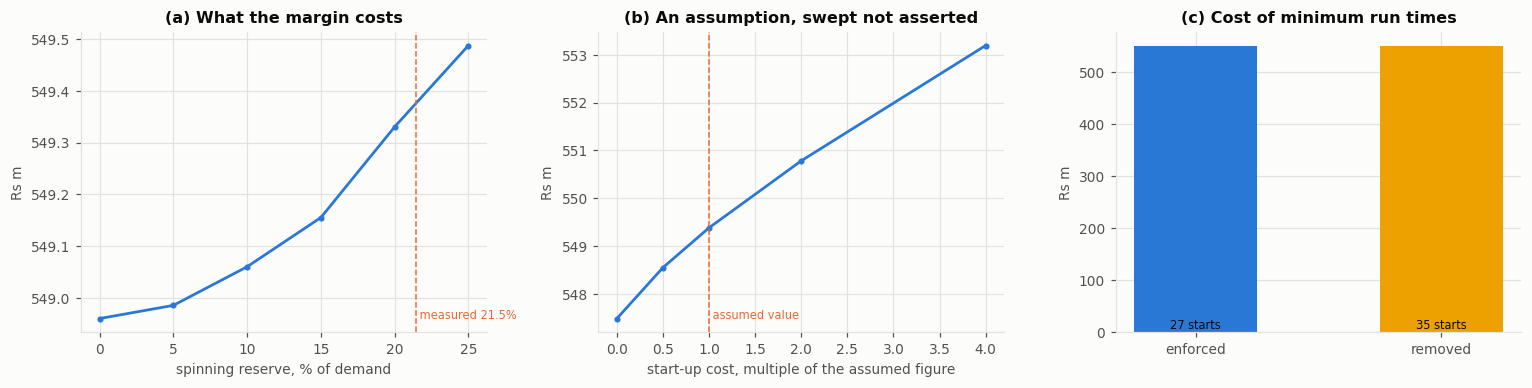

In [51]:
ab = cached("evaluation_ablations")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ax = axes[0]
reserve = ab[ab.ablation == "reserve"].groupby("level")["total_rs_m"].mean()
ax.plot(reserve.index * 100, reserve.values, color=CAT[0], marker="o", ms=3)
derived = float(instance.reserve_fraction)
ax.axvline(derived * 100, color=CAT[1], ls="--", lw=1)
ax.text(derived * 100, reserve.min(), f" measured {derived:.1%}", fontsize=7.5, color=CAT[1])
ax.set_xlabel("spinning reserve, % of demand"); ax.set_ylabel("Rs m")
ax.set_title("(a) What the margin costs")

ax = axes[1]
start = ab[ab.ablation == "start_cost"].groupby("level")[["total_rs_m", "starts"]].mean()
ax.plot(start.index, start.total_rs_m, color=CAT[0], marker="o", ms=3)
ax.axvline(1.0, color=CAT[1], ls="--", lw=1)
ax.text(1.0, start.total_rs_m.min(), " assumed value", fontsize=7.5, color=CAT[1])
ax.set_xlabel("start-up cost, multiple of the assumed figure"); ax.set_ylabel("Rs m")
ax.set_title("(b) An assumption, swept not asserted")

ax = axes[2]
mud = ab[ab.ablation == "min_up_down"].groupby("level")[["total_rs_m", "starts"]].mean()
ax.bar(["enforced", "removed"], [mud.loc[1.0, "total_rs_m"], mud.loc[0.0, "total_rs_m"]],
       color=[CAT[0], CAT[3]], width=0.5)
ax.set_ylabel("Rs m"); ax.set_title("(c) Cost of minimum run times")
for k, v in enumerate([mud.loc[1.0, "starts"], mud.loc[0.0, "starts"]]):
    ax.text(k, ax.get_ylim()[0], f"{v:.0f} starts", ha="center", va="bottom", fontsize=7.5)
fig.tight_layout(); plt.show()

These are solved by the MILP, not by the rule base, and that matters. The first attempt swept them against Arm A and two of the three came back meaningless: merit order never consults start-up cost, so scaling it returned an identical 35.92 starts at every multiplier and merely rescaled one fixed schedule; and the reserve sweep showed cost *falling* as the margin rose, which is greedy dispatch being relieved by extra committed capacity rather than anything about reserve.

## 12 · Conclusion
### What this cannot say

**The exact answer exists and the heuristics can be measured against it.** On the hourly reduction the MILP closes to proven optimality in under a minute for the full 33-unit fleet, so every claim below is anchored to a bound rather than to the best thing found.